In [1]:
# Core imports for training and evaluation
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the ML feature table exported from feature engineering
ROOT = Path.cwd().resolve()
if not (ROOT / 'data' / 'ml_df.csv').exists() and (ROOT.parent / 'data' / 'ml_df.csv').exists():
    ROOT = ROOT.parent

ml_df = pd.read_csv(ROOT / 'data' / 'ml_df.csv')
if 'date' in ml_df.columns:
    ml_df['date'] = pd.to_datetime(ml_df['date'], errors='coerce')

# Add ranking_diff if ranking scores exist
if "home_ranking_score" in ml_df.columns and "away_ranking_score" in ml_df.columns:
    ml_df["ranking_diff"] = ml_df["home_ranking_score"] - ml_df["away_ranking_score"]

ml_df.head()


,year,date,tournament_id,tournament_name,match_name,stage,home_team,away_team,home_team_code,away_team_code,...,win_rate_diff,goal_diff_diff,form_diff,goals_per_match_diff,conceded_per_match_diff,season_win_rate_diff,season_goal_diff_diff,elo_diff,result_target,ranking_diff
0,1930,1930-07-13,WC-1930,1930 FIFA World Cup,France v Mexico,Group stage,France,Mexico,FRA,MEX,...,NaN,-3.0,NaN,NaN,NaN,NaN,-3.0,0.0,HomeWin,NaN
1,1930,1930-07-13,WC-1930,1930 FIFA World Cup,United States v Belgium,Group stage,United States,Belgium,USA,BEL,...,NaN,-6.0,NaN,NaN,NaN,NaN,-6.0,0.0,HomeWin,NaN
2,1930,1930-07-14,WC-1930,1930 FIFA World Cup,Romania v Peru,Group stage,Romania,Peru,ROU,PER,...,NaN,-5.0,NaN,NaN,NaN,NaN,-5.0,0.0,HomeWin,NaN
3,1930,1930-07-14,WC-1930,1930 FIFA World Cup,Yugoslavia v Brazil,Group stage,Yugoslavia,Brazil,YUG,BRA,...,NaN,-3.0,NaN,NaN,NaN,NaN,-3.0,0.0,HomeWin,NaN
4,1930,1930-07-15,WC-1930,1930 FIFA World Cup,Argentina v France,Group stage,Argentina,France,ARG,FRA,...,NaN,-2.0,NaN,NaN,NaN,NaN,-2.0,-10.0,HomeWin,NaN


# No-Leakage Validation

Purpose: Explicitly exclude post-match fields and confirm the feature list is safe.

In [3]:
# Define allowed features and remove all post-match leakage columns.
LEAKAGE_COLS = {
    "home_goals",
    "away_goals",
    "score",
    "result",
    "home_team_win",
    "away_team_win",
    "draw",
    "extra_time",
    "penalty_shootout",
    "score_penalties",
}

# Base categorical features allowed
CATEGORICAL_COLS = [
    "stage",
    "tournament_name",
    "host_country",
    "home_team",
    "away_team",
    "tournament_size_category",
]

# Numeric engineered features (derived in long_hist with home_/away_ prefixes)
ENGINEERED_PREFIXES = [
    "home_",
    "away_",
]

feature_cols = [
    c
    for c in ml_df.columns
    if (
        c in CATEGORICAL_COLS
        or any(c.startswith(p) for p in ENGINEERED_PREFIXES)
        or c in [
            "win_rate_diff",
            "goal_diff_diff",
            "form_diff",
            "goals_per_match_diff",
            "conceded_per_match_diff",
            "season_win_rate_diff",
            "season_goal_diff_diff",
            "elo_diff",
            "ranking_diff",
            "total_teams",
            "matches_played",
            "goals_scored_tournament",
            "avg_goals_per_game",
            "year_normalized",
        ]
    )
]

# Remove leakage columns and any accidental target
feature_cols = [c for c in feature_cols if c not in LEAKAGE_COLS and c != "result_target"]

leakage_in_features = set(feature_cols) & LEAKAGE_COLS
print("Leakage columns in features:", leakage_in_features)
print("Feature count:", len(feature_cols))

Leakage columns in features: set()
Feature count: 152


# Time-Aware Train/Test Split

Purpose: Split by tournament year to avoid leakage and simulate real forecasting.

In [4]:
# Create chronological splits for train/validation/test and define X/y.
ml_df = ml_df.sort_values("date").reset_index(drop=True)

train_df = ml_df[ml_df["year"] <= 2014]
val_df = ml_df[ml_df["year"] == 2018]
test_df = ml_df[ml_df["year"] == 2022]

print("Train:", train_df.shape, train_df["year"].min(), "-", train_df["year"].max())
print("Val:", val_df.shape, val_df["year"].min(), "-", val_df["year"].max())
print("Test:", test_df.shape, test_df["year"].min(), "-", test_df["year"].max())

X_train = train_df[feature_cols]
y_train = train_df["result_target"]

X_val = val_df[feature_cols]
y_val = val_df["result_target"]

X_test = test_df[feature_cols]
y_test = test_df["result_target"]

Train: (736, 177) 1930 - 2014
Val: (62, 177) 2018 - 2018
Test: (64, 177) 2022 - 2022


# Model Training

Purpose: Fit multiple candidate models and compare on validation log loss.

In [5]:
# Build preprocessing pipelines and train baseline/ensemble models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    brier_score_loss,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)]
    )


preprocessor = build_preprocessor(X_train)

models = {
    "LogReg": LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        class_weight="balanced",
    ),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
    )

if LGBM_AVAILABLE:
    models["LightGBM"] = LGBMClassifier(
        objective="multiclass",
        n_estimators=400,
        learning_rate=0.05,
        random_state=42,
    )
else:
    models["HistGB"] = HistGradientBoostingClassifier(random_state=42)


CLASS_ORDER = ["HomeWin", "Draw", "AwayWin"]

label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)

CLASS_ORDER_ENC = list(label_encoder.transform(CLASS_ORDER))

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)


def evaluate_model(pipe: Pipeline, X, y_true, class_order) -> dict:
    preds = pipe.predict(X)
    proba = pipe.predict_proba(X)

    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average="macro")
    ll = log_loss(y_true, proba, labels=class_order)
    brier = np.mean(
        [brier_score_loss((y_true == c).astype(int), proba[:, i]) for i, c in enumerate(class_order)]
    )
    y_bin = pd.get_dummies(y_true).reindex(columns=class_order, fill_value=0)
    try:
        roc = roc_auc_score(
            y_bin,
            proba,
            multi_class="ovr",
        )
    except Exception:
        roc = np.nan
    cm = confusion_matrix(y_true, preds, labels=class_order)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "log_loss": ll,
        "brier": brier,
        "roc_auc_ovr": roc,
        "confusion_matrix": cm,
    }


results = []
model_store = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])

    if name == "XGBoost":
        pipe.fit(X_train, y_train_enc)
        metrics = evaluate_model(pipe, X_val, y_val_enc, CLASS_ORDER_ENC)
    else:
        pipe.fit(X_train, y_train)
        metrics = evaluate_model(pipe, X_val, y_val, CLASS_ORDER)

    results.append({"model": name, **metrics})
    model_store[name] = pipe

results_df = pd.DataFrame(results).sort_values("log_loss")
results_df

/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7499
[LightGBM] [Info] Number of data points in the train set: 736, number of used features: 227
[LightGBM] [Info] Start training from score -1.564278
[LightGBM] [Info] Start training from score -1.501364
[LightGBM] [Info] Start training from score -0.565749
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,macro_f1,log_loss,brier,roc_auc_ovr,confusion_matrix
2,XGBoost,0.887097,0.868632,0.255828,0.511495,0.406547,"[[22, 3, 0], [0, 10, 2], [1, 1, 23]]"
3,LightGBM,0.887097,0.869121,0.477821,0.537267,0.408619,"[[22, 2, 1], [0, 10, 2], [0, 2, 23]]"
1,RandomForest,0.838710,0.824031,0.583261,0.374392,0.345781,"[[22, 1, 2], [0, 8, 4], [3, 0, 22]]"
0,LogReg,0.580645,0.555319,0.973125,0.383526,0.361982,"[[12, 6, 7], [3, 6, 3], [3, 4, 18]]"


# Model Evaluation

Purpose: Select the best model on validation log loss and report test metrics.

In [6]:
# Make confusion matrices printable and display the ranking table.
results_df["confusion_matrix"] = results_df["confusion_matrix"].apply(lambda x: x.tolist())
results_df

,model,accuracy,macro_f1,log_loss,brier,roc_auc_ovr,confusion_matrix
2,XGBoost,0.887097,0.868632,0.255828,0.511495,0.406547,"[[22, 3, 0], [0, 10, 2], [1, 1, 23]]"
3,LightGBM,0.887097,0.869121,0.477821,0.537267,0.408619,"[[22, 2, 1], [0, 10, 2], [0, 2, 23]]"
1,RandomForest,0.838710,0.824031,0.583261,0.374392,0.345781,"[[22, 1, 2], [0, 8, 4], [3, 0, 22]]"
0,LogReg,0.580645,0.555319,0.973125,0.383526,0.361982,"[[12, 6, 7], [3, 6, 3], [3, 4, 18]]"


In [7]:
# Pick the best model and evaluate on the 2022 test set.
best_model_name = results_df.iloc[0]["model"]
best_model = model_store[best_model_name]

print("Best model by log loss:", best_model_name)

val_metrics = results_df.iloc[0].to_dict()

if best_model_name == "XGBoost":
    test_metrics = evaluate_model(best_model, X_test, y_test_enc, CLASS_ORDER_ENC)
else:
    test_metrics = evaluate_model(best_model, X_test, y_test, CLASS_ORDER)

test_metrics

Best model by log loss: XGBoost


{'accuracy': 0.921875,
 'macro_f1': 0.9162273499841557,
 'log_loss': 0.2184123935191607,
 'brier': 0.48417767278257556,
 'roc_auc_ovr': 0.4187753680364518,
 'confusion_matrix': array([[27,  1,  1],
        [ 0, 13,  2],
        [ 1,  0, 19]])}

/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Log loss before: 0.2558 after: 0.3194
Brier before: 0.5115 after: 0.4543


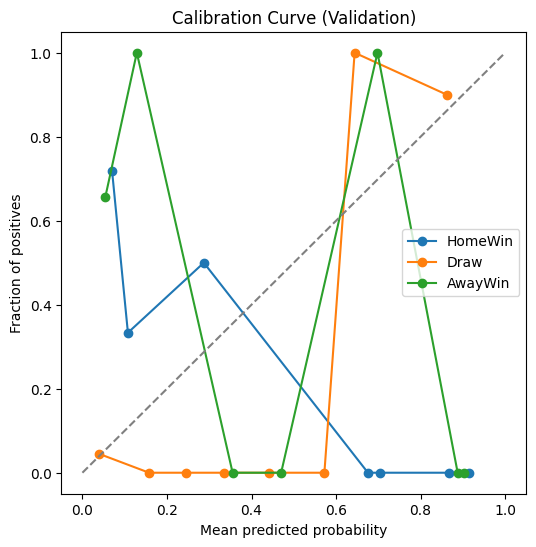

In [8]:
# Calibrate probabilities on validation data and plot reliability curves.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Probability calibration using validation split
base_proba = best_model.predict_proba(X_val)

if best_model_name == "XGBoost":
    base_log_loss = log_loss(y_val_enc, base_proba, labels=CLASS_ORDER_ENC)
    base_brier = np.mean(
        [brier_score_loss((y_val_enc == c).astype(int), base_proba[:, i]) for i, c in enumerate(CLASS_ORDER_ENC)]
    )

    calibrated = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
    calibrated.fit(X_val, y_val_enc)

    cal_proba = calibrated.predict_proba(X_val)
    cal_log_loss = log_loss(y_val_enc, cal_proba, labels=CLASS_ORDER_ENC)
    cal_brier = np.mean(
        [brier_score_loss((y_val_enc == c).astype(int), cal_proba[:, i]) for i, c in enumerate(CLASS_ORDER_ENC)]
    )
else:
    base_log_loss = log_loss(y_val, base_proba, labels=CLASS_ORDER)
    base_brier = np.mean(
        [brier_score_loss((y_val == c).astype(int), base_proba[:, i]) for i, c in enumerate(CLASS_ORDER)]
    )

    calibrated = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
    calibrated.fit(X_val, y_val)

    cal_proba = calibrated.predict_proba(X_val)
    cal_log_loss = log_loss(y_val, cal_proba, labels=CLASS_ORDER)
    cal_brier = np.mean(
        [brier_score_loss((y_val == c).astype(int), cal_proba[:, i]) for i, c in enumerate(CLASS_ORDER)]
    )

print("Log loss before:", round(base_log_loss, 4), "after:", round(cal_log_loss, 4))
print("Brier before:", round(base_brier, 4), "after:", round(cal_brier, 4))

# Calibration curve (macro average)
plt.figure(figsize=(6, 6))
for i, c in enumerate(CLASS_ORDER):
    frac_pos, mean_pred = calibration_curve((y_val == c).astype(int), cal_proba[:, i], n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=c)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Calibration Curve (Validation)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.show()


# Score Prediction (Regression)

Purpose: Train models to predict home and away goals so we can output a scoreline.

In [9]:
# Train regressors to predict home/away goals (pre-match features only)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import FunctionTransformer

# Targets
y_home = train_df["home_goals"]
y_away = train_df["away_goals"]

# Densify because HistGradientBoostingRegressor doesn't accept sparse matrices
def to_dense_fn(x):
    return x.toarray() if hasattr(x, "toarray") else x


to_dense = FunctionTransformer(to_dense_fn, accept_sparse=True)

reg_home = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("to_dense", to_dense),
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]
)
reg_away = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("to_dense", to_dense),
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]
)

reg_home.fit(X_train, y_home)
reg_away.fit(X_train, y_away)

# Evaluate on 2022 test set
pred_home = reg_home.predict(X_test)
pred_away = reg_away.predict(X_test)

mae_home = mean_absolute_error(test_df["home_goals"], pred_home)
rmse_home = np.sqrt(mean_squared_error(test_df["home_goals"], pred_home))

mae_away = mean_absolute_error(test_df["away_goals"], pred_away)
rmse_away = np.sqrt(mean_squared_error(test_df["away_goals"], pred_away))

score_metrics = pd.DataFrame({
    "target": ["home_goals", "away_goals"],
    "mae": [mae_home, mae_away],
    "rmse": [rmse_home, rmse_away],
})

score_metrics

,target,mae,rmse
0,home_goals,0.589682,0.787214
1,away_goals,0.513110,0.699558


In [10]:
# Persist the final model artifact for downstream inference.
import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_model = calibrated if cal_log_loss <= base_log_loss else best_model

artifact = {
    "model": final_model,
    "feature_cols": feature_cols,
    "class_order": CLASS_ORDER,
    "score_models": {
        "home_goals": reg_home,
        "away_goals": reg_away,
    },
}

artifact_path = MODELS_DIR / "worldcup_model.joblib"
joblib.dump(artifact, artifact_path)

print("Saved model artifact to:", artifact_path)


Saved model artifact to: /Users/jeanphilippeauguste/Downloads/DS4-World-Cup-Project-Phase/models/worldcup_model.joblib


In [11]:
# save with pickle
import pickle

pickle_path = MODELS_DIR / "worldcup_model.pkl"
with open(pickle_path, "wb") as f:
    pickle.dump(artifact, f)

print("Saved pickle artifact to:", pickle_path)

Saved pickle artifact to: /Users/jeanphilippeauguste/Downloads/DS4-World-Cup-Project-Phase/models/worldcup_model.pkl
